In [2]:
import pandas as pd

# Ruta del archivo
file_path = "../data/household_power_consumption.txt"

# Cargar dataset
df = pd.read_csv(
    file_path,
    sep=";",
    low_memory=False
)

# Mostrar primeras filas
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [3]:
df.info()

#Visualizamos los datos para ver si estan de manera numérica
#Empezamos el Data Cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [4]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


In [5]:
df.set_index("Datetime", inplace=True)

df.head()

#Convertimos en serie temporal la fecha y la hora

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [6]:
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

#convertimos texto en números 

In [7]:
df.isnull().sum()

#Visualizamos cuantos datos faltan

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [8]:
df = df.dropna()

df.isnull().sum()

#Eliminamos valores faltantes ya que eran muy pocos los que faltaban, solo el 1,25% así que decidimos no interpolarlos.

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [9]:
df.shape

(2049280, 9)

In [10]:
#Primer análisis temporal

daily_power = df["Global_active_power"].resample("D").mean()

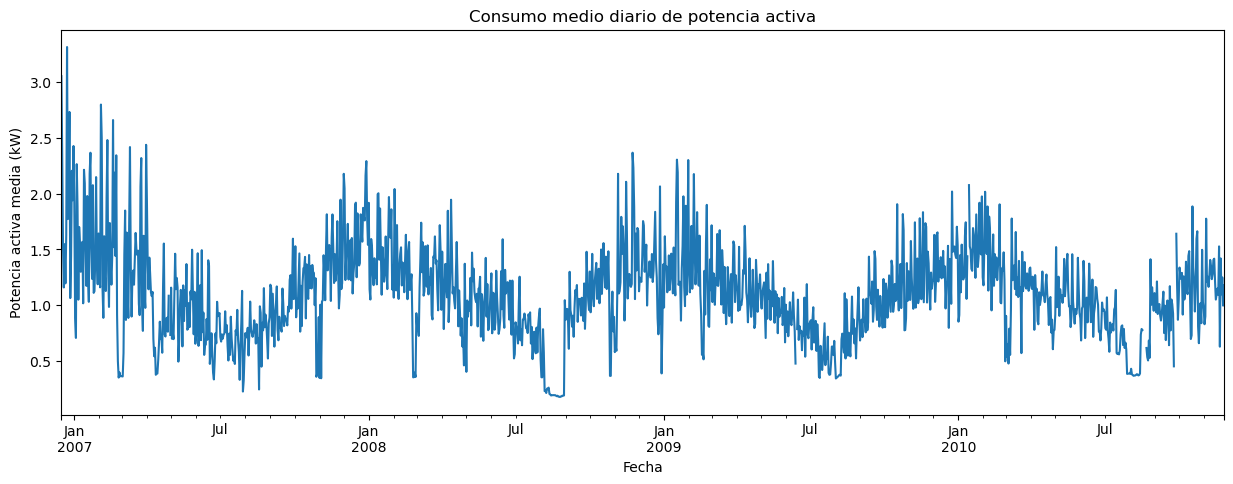

In [11]:
#Creamos nuestra primera gráfica

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

daily_power.plot()

plt.title("Consumo medio diario de potencia activa")
plt.xlabel("Fecha")
plt.ylabel("Potencia activa media (kW)")

plt.show()

In [12]:
#Se observa un comportamiento estacional del consumo energético, con mayores valores durante los meses de invierno y menores durante el verano.
df = df.dropna()

df.shape

(2049280, 9)

In [13]:
df["Hour"] = df.index.hour

In [14]:
hourly_power = df.groupby("Hour")["Global_active_power"].mean()

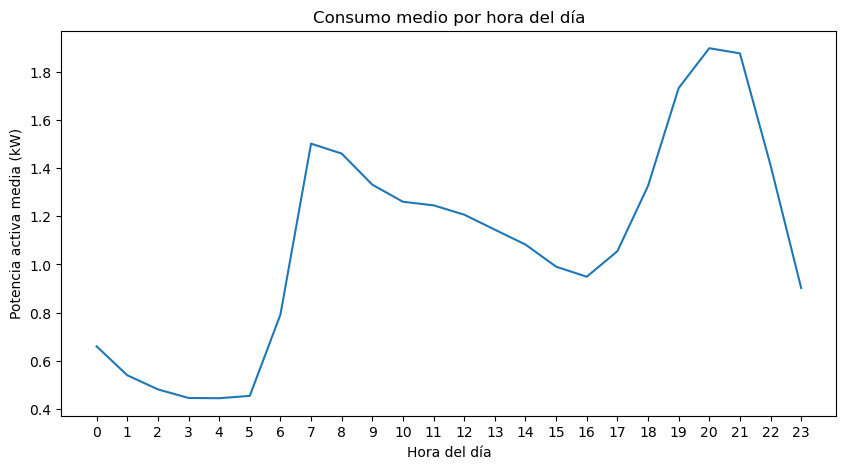

In [15]:
plt.figure(figsize=(10,5))

hourly_power.plot()

plt.title("Consumo medio por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Potencia activa media (kW)")

plt.xticks(range(0,24))

plt.show()

In [16]:
#Se observa que el consumo energético mínimo se produce durante las horas de madrugada, entre las 02:00 y las 05:00, coincidiendo con los periodos de menor actividad doméstica.
#Ya sabemos que esto es lo que significa cada sub_metering
#Sub_metering_1: kitchen appliances
#Sub_metering_2: laundry room
#Sub_metering_3: water-heater and air-conditioner

sub_metering_mean = df[
    ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
].mean()

sub_metering_mean

Sub_metering_1    1.121923
Sub_metering_2    1.298520
Sub_metering_3    6.458447
dtype: float64

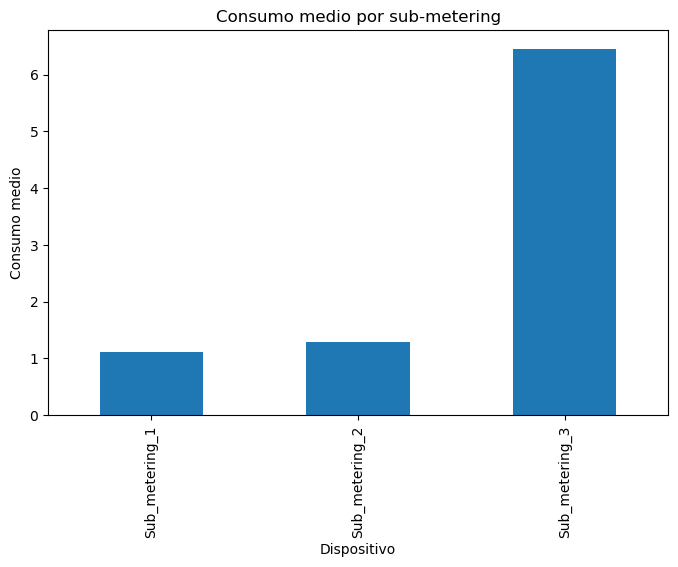

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sub_metering_mean.plot(kind="bar")

plt.title("Consumo medio por sub-metering")
plt.xlabel("Dispositivo")
plt.ylabel("Consumo medio")

plt.show()

In [18]:
sub_hourly = df.groupby("Hour")[
    ["Sub_metering_1",
     "Sub_metering_2",
     "Sub_metering_3"]
].mean()

sub_hourly.head()

,Sub_metering_1,Sub_metering_2,Sub_metering_3
Hour,,,
0,0.364378,0.555392,2.966651
1,0.248958,0.397963,2.351931
2,0.145858,0.350133,2.027166
3,0.067765,0.350061,1.692080
4,0.047142,0.334048,1.866275


<Figure size 1200x600 with 0 Axes>

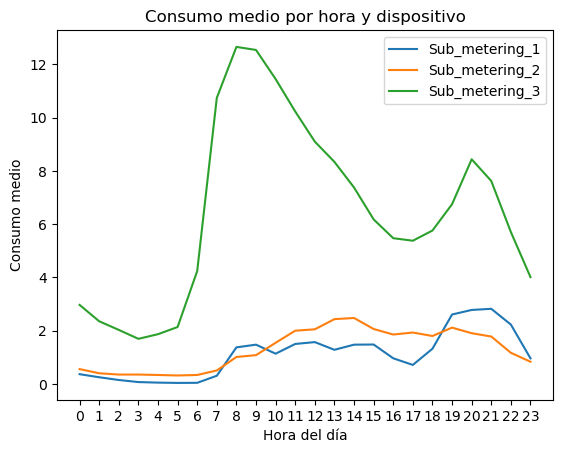

In [19]:
plt.figure(figsize=(12,6))

sub_hourly.plot()

plt.title("Consumo medio por hora y dispositivo")
plt.xlabel("Hora del día")
plt.ylabel("Consumo medio")

plt.xticks(range(0,24))

plt.show()

In [20]:
hourly_mean = df.groupby("Hour")["Global_active_power"].mean()

hourly_mean

Hour
0     0.659434
1     0.539325
2     0.480621
3     0.444866
4     0.443847
5     0.453674
6     0.791600
7     1.502246
8     1.461016
9     1.331645
10    1.260627
11    1.245822
12    1.207075
13    1.144532
14    1.082839
15    0.990760
16    0.948905
17    1.055109
18    1.326451
19    1.733335
20    1.899064
21    1.877697
22    1.412615
23    0.902142
Name: Global_active_power, dtype: float64

In [21]:
lowest_hours = hourly_mean.sort_values().head(5)

lowest_hours

Hour
4    0.443847
3    0.444866
5    0.453674
2    0.480621
1    0.539325
Name: Global_active_power, dtype: float64

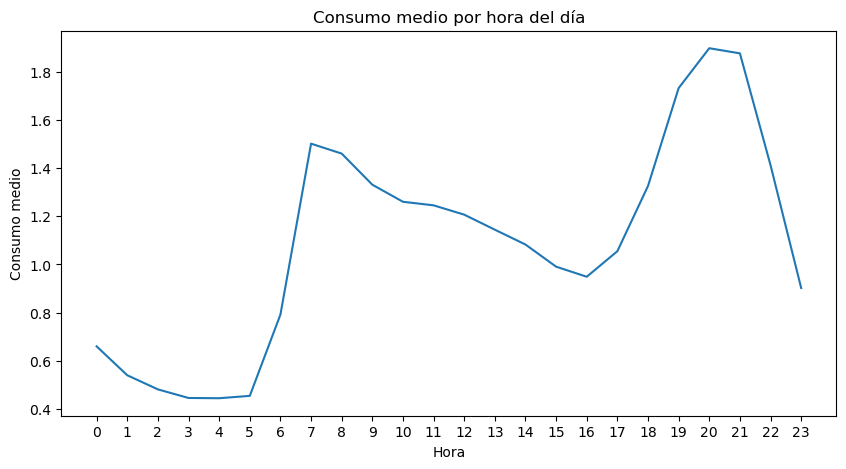

In [22]:
plt.figure(figsize=(10,5))

hourly_mean.plot()

plt.title("Consumo medio por hora del día")
plt.xlabel("Hora")
plt.ylabel("Consumo medio")

plt.xticks(range(0,24))

plt.show()

In [23]:
# Consumo medio por hora
hourly_consumption = df.groupby("Hour")["Global_active_power"].mean()

hourly_consumption

Hour
0     0.659434
1     0.539325
2     0.480621
3     0.444866
4     0.443847
5     0.453674
6     0.791600
7     1.502246
8     1.461016
9     1.331645
10    1.260627
11    1.245822
12    1.207075
13    1.144532
14    1.082839
15    0.990760
16    0.948905
17    1.055109
18    1.326451
19    1.733335
20    1.899064
21    1.877697
22    1.412615
23    0.902142
Name: Global_active_power, dtype: float64

In [24]:
hourly_consumption_df = hourly_consumption.reset_index()

hourly_consumption_df.columns = [
    "Hour",
    "avg_consumption_kwh"
]

hourly_consumption_df.head()

,Hour,avg_consumption_kwh
0,0,0.659434
1,1,0.539325
2,2,0.480621
3,3,0.444866
4,4,0.443847


In [25]:
hourly_consumption_df.to_csv(
    "../data/hourly_consumption.csv",
    index=False
)

In [26]:
df["DayOfWeek"] = df.index.dayofweek
weekly = df.groupby("DayOfWeek")["Global_active_power"].mean()

In [27]:
df["unmetered"] = df["Global_active_power"] - (
    df["Sub_metering_1"] + df["Sub_metering_2"] + df["Sub_metering_3"]
) / 1000